<a href="https://colab.research.google.com/github/MDADILIFTEKHAR/Healthcare-Analytics-for-Doctor-Visits-TIRTC/blob/main/Healthcare_Analytics_for_Doctor_Visits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('/content/1776250375-P2-Healthcare Analytics for Doctor Visits.csv')

In [3]:
df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [4]:
df.tail()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,5186,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,5187,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,5188,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,5189,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,5190,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


In [5]:
df.shape

(5190, 13)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [9]:
df.describe()

,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,2595.500000,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,1498.368279,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,1.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,1298.250000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,2595.500000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,3892.750000,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,5190.000000,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [10]:
df.isnull().sum()

,0
Unnamed: 0,0
visits,0
gender,0
age,0
income,0
illness,0
reduced,0
health,0
private,0
freepoor,0


### Univariate Plots

Let's start by visualizing the distribution of the `age` variable using a histogram.

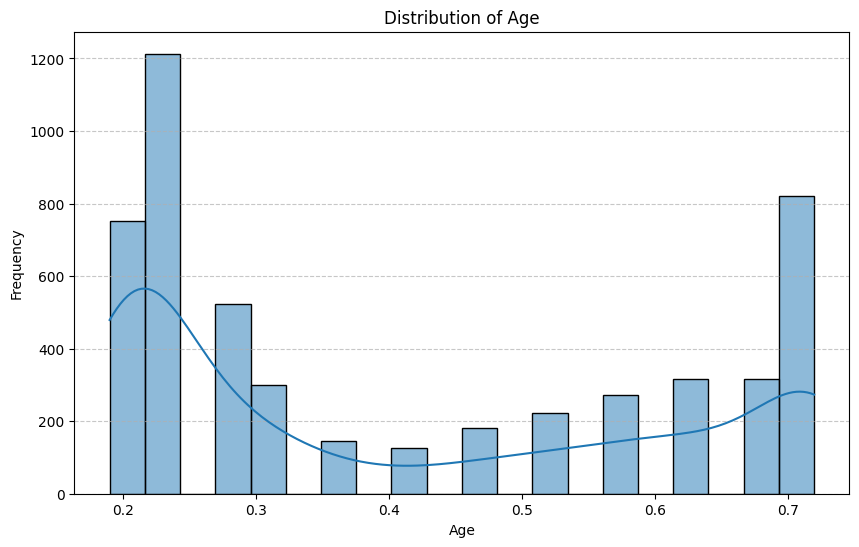

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Next, let's look at the distribution of `gender` using a countplot.

/tmp/ipykernel_1220/4120179950.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df, palette='viridis')


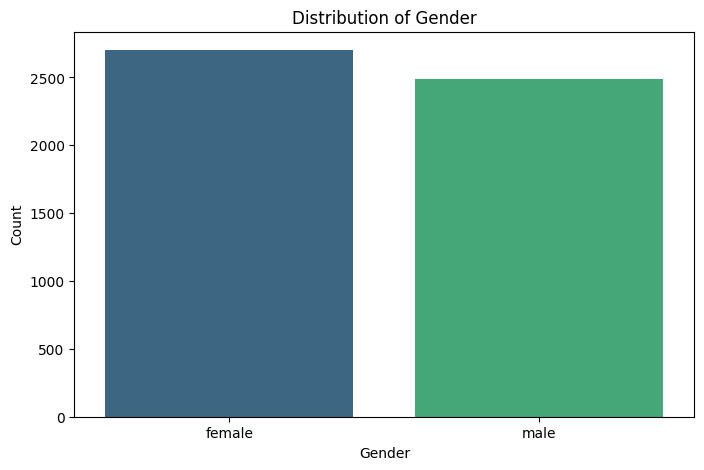

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(x='gender', data=df, palette='viridis')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

Finally, let's visualize the distribution and potential outliers of `income` using a boxplot.

/tmp/ipykernel_1220/3488018696.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='income', data=df, palette='plasma')


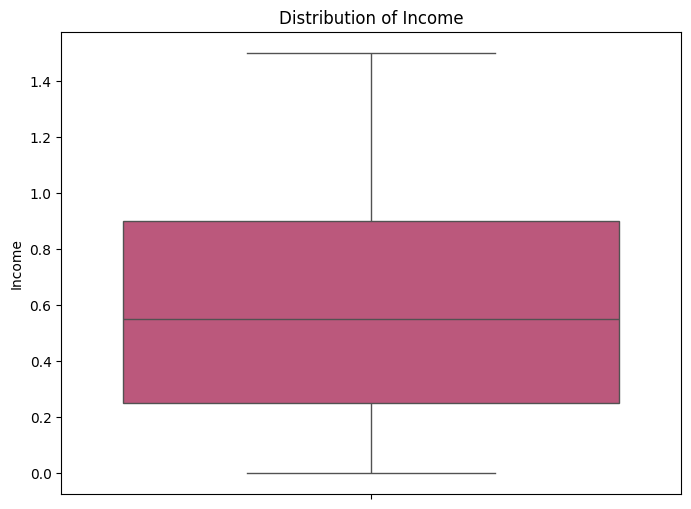

In [13]:
plt.figure(figsize=(8, 6))
sns.boxplot(y='income', data=df, palette='plasma')
plt.title('Distribution of Income')
plt.ylabel('Income')
plt.show()

### Gender Analysis

Let's analyze how various numerical features differ between genders by calculating the mean of 'visits', 'illness', 'reduced', 'health', 'age', and 'income' for 'female' and 'male' groups.

In [14]:
gender_analysis = df.groupby('gender')[['visits', 'illness', 'reduced', 'health', 'age', 'income']].mean()
display(gender_analysis)

,visits,illness,reduced,health,age,income
gender,,,,,,
female,0.361954,1.611029,0.975574,1.334567,0.461625,0.485252
male,0.236334,1.237540,0.738344,1.090434,0.346395,0.689490


To better visualize the difference, let's plot the average number of visits by gender.

/tmp/ipykernel_1220/1660282324.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_analysis.index, y=gender_analysis['visits'], palette='coolwarm')


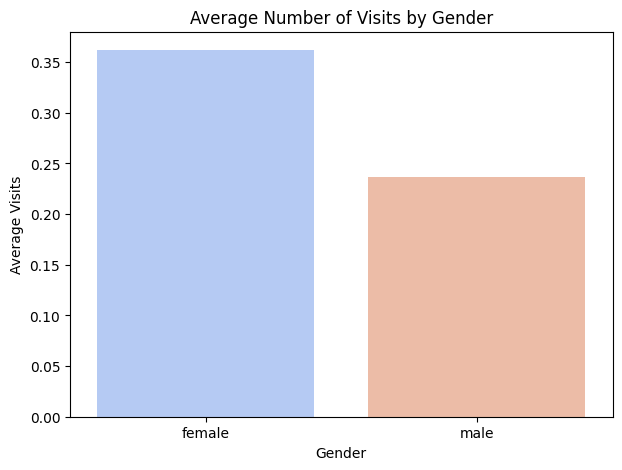

In [15]:
plt.figure(figsize=(7, 5))
sns.barplot(x=gender_analysis.index, y=gender_analysis['visits'], palette='coolwarm')
plt.title('Average Number of Visits by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Visits')
plt.show()

### Multivariate Plot: Age, Income, and Gender

Let's visualize the relationship between 'age' and 'income' and how it varies by 'gender' using a scatter plot. This will help identify any patterns or clusters based on gender.

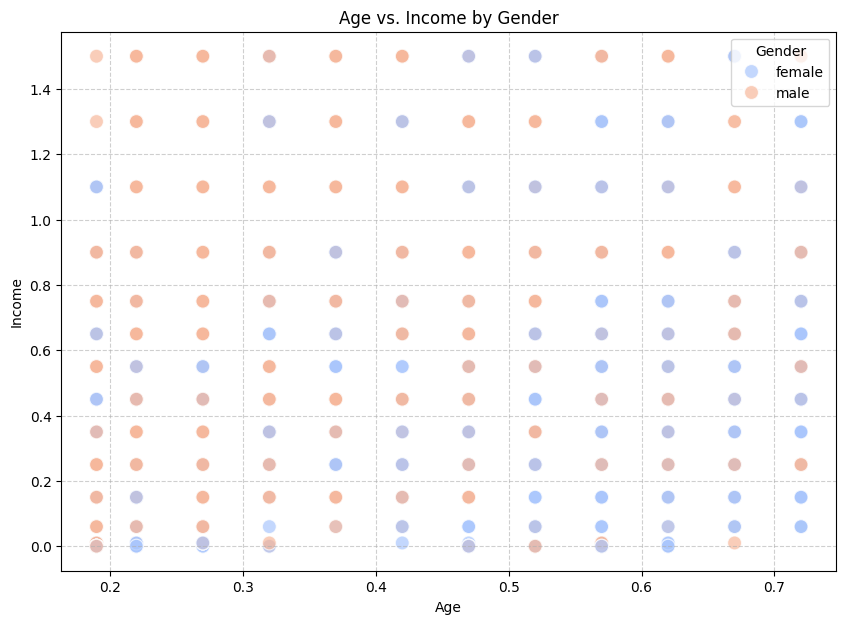

In [16]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='age', y='income', hue='gender', data=df, palette='coolwarm', s=100, alpha=0.7)
plt.title('Age vs. Income by Gender')
plt.xlabel('Age')
plt.ylabel('Income')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Gender')
plt.show()